In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:

# 1. Define the Neural Network Models
def create_model(activation='sigmoid'):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(50, activation=activation),
        tf.keras.layers.Dense(50, activation=activation),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model


In [4]:
# 2. Setup Data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


In [5]:

# 3. Define Training Function (or use model.fit)
def train_model(model, x_train, y_train, x_test, y_test, epochs=10):
    model.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=epochs, 
                        validation_data=(x_test, y_test), verbose=1)
    return history.history

In [6]:
# Train with Sigmoid
model_sigmoid = create_model(activation='sigmoid')
history_sigmoid = train_model(model_sigmoid, x_train, y_train, x_test, y_test)

# Train with ReLU
model_relu = create_model(activation='relu')
history_relu = train_model(model_relu, x_train, y_train, x_test, y_test)

c:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3098 - loss: 2.2305 - val_accuracy: 0.4664 - val_loss: 2.1127
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5741 - loss: 1.8730 - val_accuracy: 0.6428 - val_loss: 1.5552
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6855 - loss: 1.2956 - val_accuracy: 0.7505 - val_loss: 1.0591
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7663 - loss: 0.9365 - val_accuracy: 0.8089 - val_loss: 0.8076
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8156 - loss: 0.7456 - val_accuracy: 0.8420 - val_loss: 0.6607
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8449 - loss: 0.6252 - val_accuracy: 0.8609 - val_loss: 0.5630
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8627 - loss: 0.5427 - val_accuracy: 0.8743 - val_loss: 0.4946
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8749 - loss: 0.4846 - 

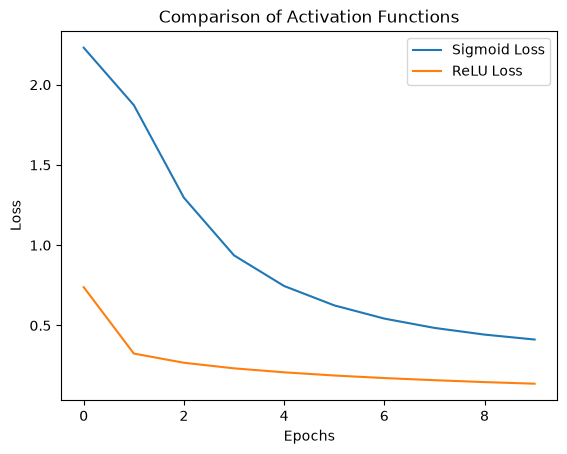

In [7]:
# Plotting Loss
plt.plot(history_sigmoid['loss'], label='Sigmoid Loss')
plt.plot(history_relu['loss'], label='ReLU Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Comparison of Activation Functions')
plt.show()